<a href="https://colab.research.google.com/github/odamasceno/Calculo-Numerico/blob/main/Atividade_pr%C3%A1tica_Vers%C3%A3o_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Rafael Damasceno Marques dos Santos - RA: 187561

In [14]:
#Bibliotecas Necessárias
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
#função para truncamento
def truncamento(n, x):
  return math.trunc((10**n)*x)/ 10**n


## 3 - Parte A

,Valor de Ref (x),Casas (n),Truncado,Arredondado,Ea Trunc,Ea Arred,Er Trunc,Er Arred,E% Trunc,E% Arred
0,3.1416e+00,0,3.0000e+00,3.0000e+00,1.4159e-01,1.4159e-01,4.5070e-02,4.5070e-02,4.5070e+00,4.5070e+00
1,3.1416e+00,1,3.1000e+00,3.1000e+00,4.1593e-02,4.1593e-02,1.3239e-02,1.3239e-02,1.3239e+00,1.3239e+00
2,3.1416e+00,2,3.1400e+00,3.1400e+00,1.5927e-03,1.5927e-03,5.0696e-04,5.0696e-04,5.0696e-02,5.0696e-02
3,3.1416e+00,3,3.1410e+00,3.1420e+00,5.9265e-04,4.0735e-04,1.8865e-04,1.2966e-04,1.8865e-02,1.2966e-02
4,3.1416e+00,4,3.1415e+00,3.1416e+00,9.2650e-05,7.3500e-06,2.9491e-05,2.3396e-06,2.9491e-03,2.3396e-04
5,9.8765e+01,0,9.8000e+01,9.9000e+01,7.6543e-01,2.3457e-01,7.7500e-03,2.3750e-03,7.7500e-01,2.3750e-01
6,9.8765e+01,1,9.8700e+01,9.8800e+01,6.5430e-02,3.4570e-02,6.6248e-04,3.5002e-04,6.6248e-02,3.5002e-02
7,9.8765e+01,2,9.8760e+01,9.8770e+01,5.4300e-03,4.5700e-03,5.4979e-05,4.6271e-05,5.4979e-03,4.6271e-03
8,9.8765e+01,3,9.8765e+01,9.8765e+01,4.3000e-04,4.3000e-04,4.3538e-06,4.3538e-06,4.3538e-04,4.3538e-04
9,9.8765e+01,4,9.8765e+01,9.8765e+01,3.0000e-05,3.0000e-05,3.0375e-07,3.0375e-07,3.0375e-05,3.0375e-05


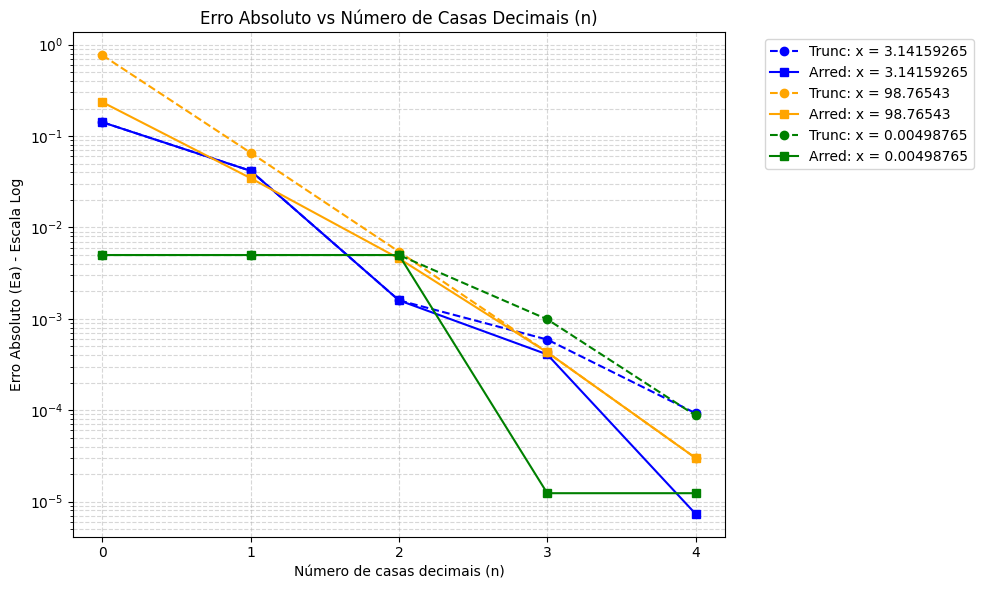

In [16]:
x = [3.14159265, 98.76543, 0.00498765]
n = [0,1,2,3,4]

linhas_tabela = []

for xi in x:
  for ni in n:
    #calculando a aproximação por truncamento e por arredondamento em cada X, com cada N
    xtrunc = truncamento(ni,xi)
    xarrend = round(xi,ni)

    #calculo do erro absoluto:
    erroAbsTrunc = abs(xi - xtrunc)
    erroAbsArrend = abs(xi - xarrend)

    #calculo do erro Relativo:
    erroRelTrunc = erroAbsTrunc/abs(xi)
    erroRelArrend = erroAbsArrend/abs(xi)

    #Erros percentuais
    percentTrunc = 100*erroRelTrunc
    percentArrend = 100*erroRelArrend

    linhas_tabela.append({
        'Valor de Ref (x)': xi,
        'Casas (n)': ni,
        'Truncado': xtrunc,
        'Arredondado': xarrend,
        'Ea Trunc': erroAbsTrunc,
        'Ea Arred': erroAbsArrend,
        'Er Trunc': erroRelTrunc,
        'Er Arred': erroRelArrend,
        'E% Trunc': percentTrunc,
        'E% Arred': percentArrend
    })

# Criando e exibindo a tabela
tabela_df = pd.DataFrame(linhas_tabela)
display(tabela_df)

plt.figure(figsize=(10, 6))



# Cores para diferenciar cada valor de x
cores = ['blue', 'orange', 'green']

for i, xi in enumerate(x):
    dados_x = tabela_df[tabela_df['Valor de Ref (x)'] == xi]
    plt.plot(dados_x['Casas (n)'], dados_x['Ea Trunc'],
             linestyle='--', marker='o', color=cores[i],
             label=f'Trunc: x = {xi}')

    plt.plot(dados_x['Casas (n)'], dados_x['Ea Arred'],
             linestyle='-', marker='s', color=cores[i],
             label=f'Arred: x = {xi}')

# Configurando o gráfico
plt.yscale('log')
plt.xlabel('Número de casas decimais (n)')
plt.ylabel('Erro Absoluto (Ea) - Escala Log')
plt.title('Erro Absoluto vs Número de Casas Decimais (n)')
plt.xticks(n)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()


### **Resposta 5**
Sim, arredondar sempre gera um erro menor ou igual ao truncamento. Ao analisar os resultados do grafico e da tabela, é possível observar que os valores obtidos pelo arredondamento são sempre inferiores ou iguais ao do truncamento, isso ocorre por conta da forma como a aproximação é efetuada em cada um dos casos

## 4 - Parte B

In [17]:
#Criação das Séries - Parte B1
s1 = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
s2 = np.round(s1)
s3 = np.trunc(s1) #n = 0, entao da pra usar a propria função

media_ref = np.mean(s1)
media_s2 = np.mean(s2)
media_s3 = np.mean(s3)

#Obtenção dos dados
def calc_dados(nome_serie, dados):
    media = np.mean(dados)
    minimo = np.min(dados)
    maximo = np.max(dados)
    amplitude = maximo - minimo

    desvio_padrao = np.std(dados, ddof=1)

    ea_media = abs(media_ref - media)
    er_media = ea_media / abs(media_ref)
    ep_media = 100 * er_media

    return {
        'Série': nome_serie,
        'Média': media,
        'Mínimo': minimo,
        'Máximo': maximo,
        'Amplitude': amplitude,
        'Desv-Padrão': desvio_padrao,
        'Ea (Média)': ea_media,
        'Er (Média)': er_media,
        'E% (Média)': ep_media
    }

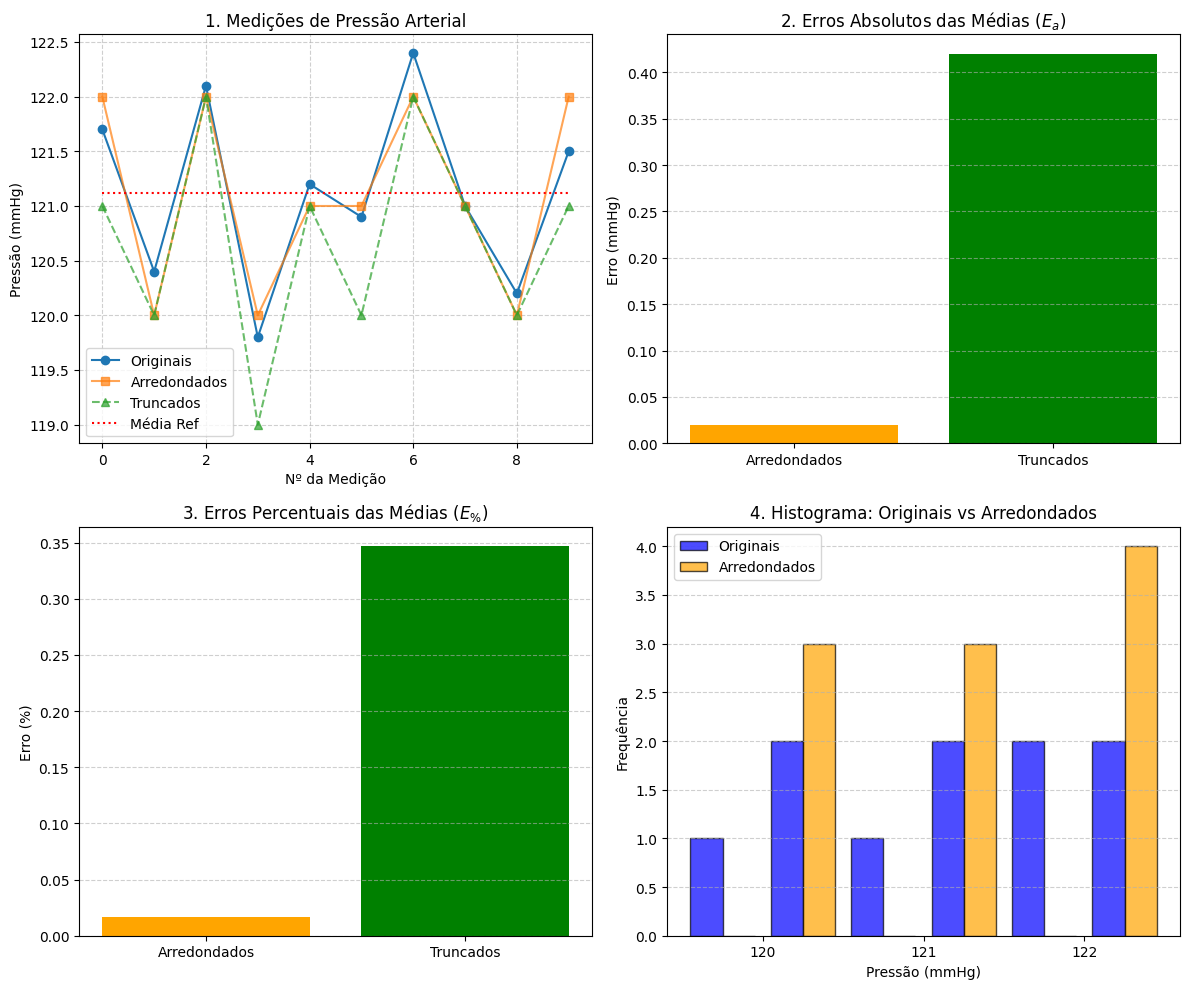

In [18]:
#Parte B2 - Graficos

media_ref_array = np.full(len(s1), media_ref)


ea_s2 = abs(media_ref - media_s2)
ea_s3 = abs(media_ref - media_s3)

ep_s2 = 100 * (ea_s2 / abs(media_ref))
ep_s3 = 100 * (ea_s3 / abs(media_ref))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(s1, marker='o', label='Originais')
ax[0, 0].plot(s2, marker='s', label='Arredondados', alpha=0.7)
ax[0, 0].plot(s3, marker='^', linestyle='--', label='Truncados', alpha=0.7)
ax[0, 0].plot(media_ref_array, color='red', linestyle=':', label='Média Ref')
ax[0, 0].set_title('1. Medições de Pressão Arterial')
ax[0, 0].set_xlabel('Nº da Medição')
ax[0, 0].set_ylabel('Pressão (mmHg)')
ax[0, 0].legend()
ax[0, 0].grid(True, linestyle='--', alpha=0.6)

#Gráfico de barras dos Erros Absolutos
labels = ['Arredondados', 'Truncados']
erros_abs = [ea_s2, ea_s3]
ax[0, 1].bar(labels, erros_abs, color=['orange', 'green'])
ax[0, 1].set_title('2. Erros Absolutos das Médias ($E_a$)')
ax[0, 1].set_ylabel('Erro (mmHg)')
ax[0, 1].grid(axis='y', linestyle='--', alpha=0.6)

#Gráfico de barras dos Erros Percentuais
erros_perc = [ep_s2, ep_s3]
ax[1, 0].bar(labels, erros_perc, color=['orange', 'green'])
ax[1, 0].set_title(r'3. Erros Percentuais das Médias ($E_{\%}$)')
ax[1, 0].set_ylabel('Erro (%)')
ax[1, 0].grid(axis='y', linestyle='--', alpha=0.6)

#Histograma dos originais vs inteiros arredondados
bins = np.arange(119.5, 123.0, 0.5)
ax[1, 1].hist([s1, s2], bins=bins, label=['Originais', 'Arredondados'], color=['blue', 'orange'],  alpha=0.7,  edgecolor='black')

ax[1, 1].set_title('4. Histograma: Originais vs Arredondados')
ax[1, 1].set_xlabel('Pressão (mmHg)')
ax[1, 1].set_ylabel('Frequência')
ax[1, 1].set_xticks([120, 121, 122])
ax[1, 1].grid(axis='y', linestyle='--', alpha=0.6)
ax[1, 1].legend()

plt.tight_layout()
plt.show()

### Resposta final : "Explique se a representação inteira é suficiente para preservar a média e a variabilidade desta pequena amostra. Não faça interpretação médica dos valores."

Não, a representação inteira não é totalmente suficiente. Em relação à média, apenas a representação inteira por arredondamento consegue preservá-la com erros absoluto e percentual baixos, enquanto o truncamento a distorce significativamente. Além disso, pelo histograma, é possível observar uma perda de variabilidade em ambas as representações inteiras: valores originais que apresentavam diferenças sutis nas casas decimais acabaram se tornando iguais

## 5 - Parte C

In [19]:
#Valores Fornecidos

r = 0.80
L = 0.20
u = (3.5)*(10**-3)
dP = 1200

#Aproximações
rArrend = round(r, 1)
rTrunc =  truncamento(1, r)

uArrend = round(u, 3)
uTrunc = truncamento(3, u)

dPArrend = round(dP, -2)
dPTrunc = truncamento(-2, dP)


#Formula Geral
def HagenPoiseuille(R, deltaP, mi, l):
  return (math.pi * (R**4) * deltaP) / (8 * mi * l)

#Aplicando aproximações
Q_ref = HagenPoiseuille(r, dP, u, L)

Q_rArrend = HagenPoiseuille(rArrend, dP, u, L)
Q_rTrunc = HagenPoiseuille(rTrunc, dP, u, L)

Q_uArrend = HagenPoiseuille(r, dP, uArrend, L)
Q_uTrunc = HagenPoiseuille(r, dP, uTrunc, L)

Q_dPArrend = HagenPoiseuille(r, dPArrend, u, L)
Q_dPTrunc = HagenPoiseuille(r, dPTrunc, u, L)

Q_todasArrend = HagenPoiseuille(rArrend, dPArrend, uArrend, L)
Q_todasTrunc = HagenPoiseuille(rTrunc, dPTrunc, uTrunc, L)

#Calculando os Erros
resultados_vazao = {
    'Cenário': ['r Arredondado', 'r Truncado', 'u Arredondado', 'u Truncado', 'dP Arredondado', 'dP Truncado', 'Todas Arred', 'Todas Trunc'],
    'Q (Vazão)': [Q_rArrend, Q_rTrunc, Q_uArrend, Q_uTrunc, Q_dPArrend, Q_dPTrunc, Q_todasArrend, Q_todasTrunc],
    'Erro Absoluto': [],
    'Erro Relativo': [],
    'Erro Percentual': []
}
for q_aprox in resultados_vazao['Q (Vazão)']:
    ea = abs(Q_ref - q_aprox)
    er = ea / abs(Q_ref)
    ep = 100 * er

    resultados_vazao['Erro Absoluto'].append(ea)
    resultados_vazao['Erro Relativo'].append(er)
    resultados_vazao['Erro Percentual'].append(ep)


#Resultados
tabela_erros_c1 = pd.DataFrame(resultados_vazao)
pd.options.display.float_format = '{:.4e}'.format
display(tabela_erros_c1)




,Cenário,Q (Vazão),Erro Absoluto,Erro Relativo,Erro Percentual
0,r Arredondado,2.7574e+05,0.0000e+00,0.0000e+00,0.0000e+00
1,r Truncado,2.7574e+05,0.0000e+00,0.0000e+00,0.0000e+00
2,u Arredondado,2.4127e+05,3.4468e+04,1.2500e-01,1.2500e+01
3,u Truncado,3.2170e+05,4.5957e+04,1.6667e-01,1.6667e+01
4,dP Arredondado,2.7574e+05,0.0000e+00,0.0000e+00,0.0000e+00
5,dP Truncado,2.7574e+05,0.0000e+00,0.0000e+00,0.0000e+00
6,Todas Arred,2.4127e+05,3.4468e+04,1.2500e-01,1.2500e+01
7,Todas Trunc,3.2170e+05,4.5957e+04,1.6667e-01,1.6667e+01


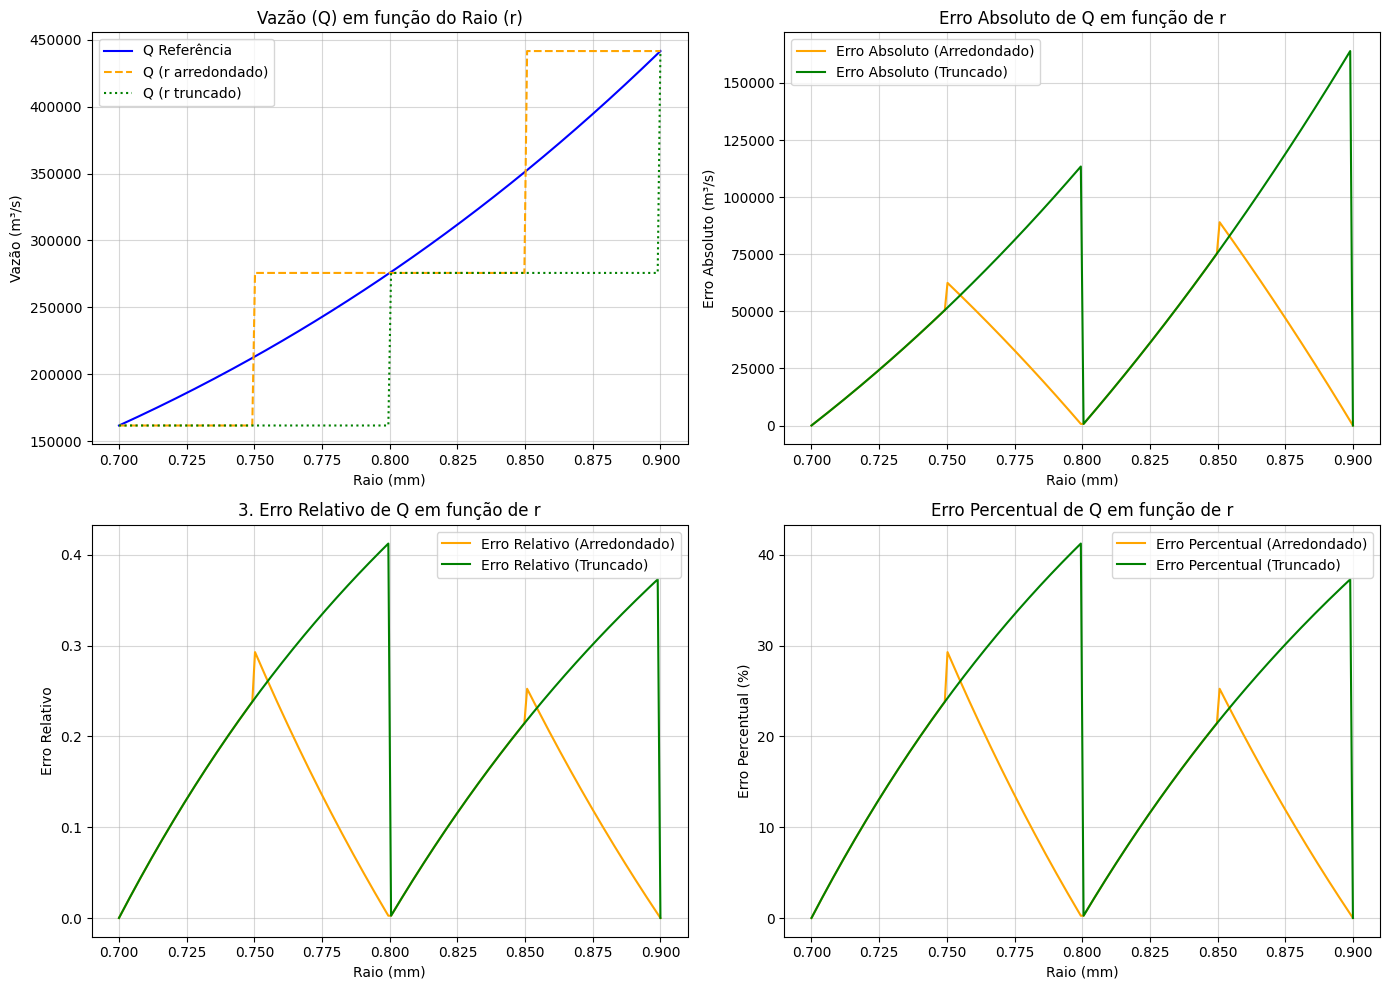

In [20]:
#Parte C2

def truncamento_array(n, x_array):
    return np.trunc(x_array * (10**n)) / (10**n)

#Gerando os raios
raios_ref = np.linspace(0.70, 0.90, 200)


raios_arred = np.round(raios_ref, 1)
raios_trunc = truncamento_array(1, raios_ref)


# Calculando as Vazões (Q)
Q_ref_c2 = HagenPoiseuille(raios_ref, dP, u, L)
Q_arred_c2 = HagenPoiseuille(raios_arred, dP, u, L)
Q_trunc_c2 = HagenPoiseuille(raios_trunc, dP, u, L)

# Erro do Raio Arredondado
ea_arred = abs(Q_ref_c2 - Q_arred_c2)
er_arred = ea_arred / abs(Q_ref_c2)
ep_arred = 100 * er_arred

# Erro do Raio Truncado
ea_trunc = abs(Q_ref_c2 - Q_trunc_c2)
er_trunc = ea_trunc / abs(Q_ref_c2)
ep_trunc = 100 * er_trunc


#Gerando os Graficos
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

#Q em função de r
ax[0, 0].plot(raios_ref, Q_ref_c2, label='Q Referência', color='blue')
ax[0, 0].plot(raios_ref, Q_arred_c2, label='Q (r arredondado)', linestyle='--', color='orange')
ax[0, 0].plot(raios_ref, Q_trunc_c2, label='Q (r truncado)', linestyle=':', color='green')
ax[0, 0].set_title('Vazão (Q) em função do Raio (r)')
ax[0, 0].set_xlabel('Raio (mm)')
ax[0, 0].set_ylabel('Vazão (m³/s)')
ax[0, 0].legend()
ax[0, 0].grid(True, alpha=0.5)

#Erro Absoluto de Q
ax[0, 1].plot(raios_ref, ea_arred, label='Erro Absoluto (Arredondado)', color='orange')
ax[0, 1].plot(raios_ref, ea_trunc, label='Erro Absoluto (Truncado)', color='green')
ax[0, 1].set_title('Erro Absoluto de Q em função de r')
ax[0, 1].set_xlabel('Raio (mm)')
ax[0, 1].set_ylabel('Erro Absoluto (m³/s)')
ax[0, 1].legend()
ax[0, 1].grid(True, alpha=0.5)

#Erro Relativo de Q
ax[1, 0].plot(raios_ref, er_arred, label='Erro Relativo (Arredondado)', color='orange')
ax[1, 0].plot(raios_ref, er_trunc, label='Erro Relativo (Truncado)', color='green')
ax[1, 0].set_title('3. Erro Relativo de Q em função de r')
ax[1, 0].set_xlabel('Raio (mm)')
ax[1, 0].set_ylabel('Erro Relativo')
ax[1, 0].legend()
ax[1, 0].grid(True, alpha=0.5)

#Erro Percentual de Q
ax[1, 1].plot(raios_ref, ep_arred, label='Erro Percentual (Arredondado)', color='orange')
ax[1, 1].plot(raios_ref, ep_trunc, label='Erro Percentual (Truncado)', color='green')
ax[1, 1].set_title('Erro Percentual de Q em função de r')
ax[1, 1].set_xlabel('Raio (mm)')
ax[1, 1].set_ylabel('Erro Percentual (%)')
ax[1, 1].legend()
ax[1, 1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### Resposta da Questão: Explique por que o erro no raio é amplificado na vazão. Relacione sua resposta ao expoente quatro.

O erro no raio é amplificado na vazão devido à forma como a equação de Hagen-Poiseuille foi determinada. A equação utiliza o raio elevado à quarta potência, com isso o erro não irá crescer de forma linear e proporcional, mas sim proporcional à quarta potência, fazendo com que mesmo pequenas variações gerem erros muito maiores.


## 6 - Parte D

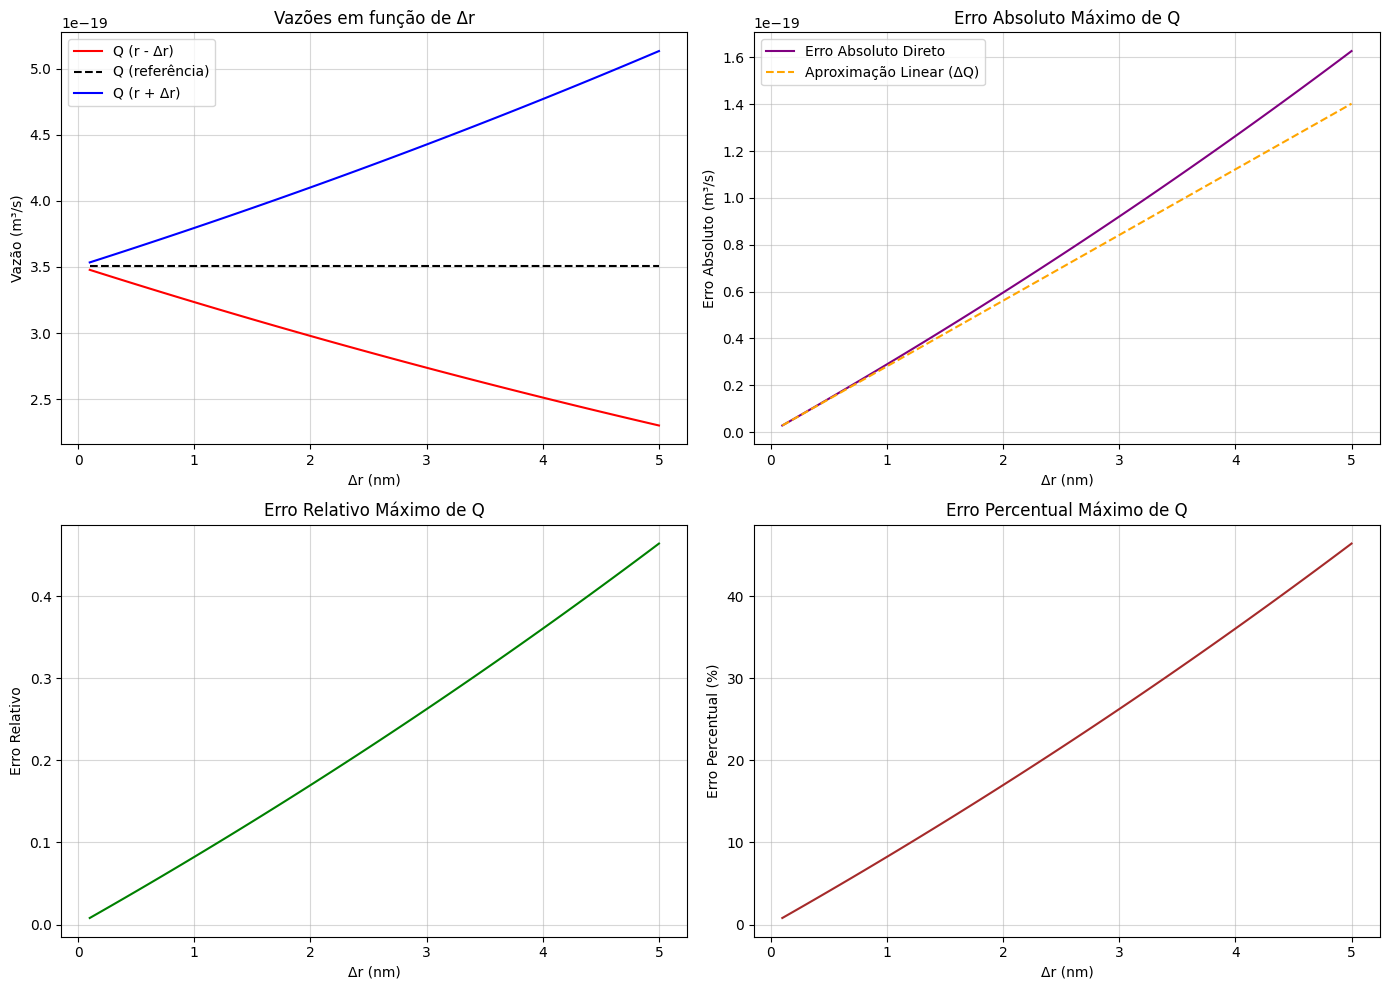

In [21]:

#Parte D1
r_nm = 50 #nm
L_um = 10 # um
u = 3.5 * (10**-3) # Pa s
dP = 5000 #Pa

# Conversão para Metros
r = r_nm * (10**-9)
L = L_um * (10**-6)

#  Vazão de referência (Q)
Q_ref = HagenPoiseuille(r, dP, u, L)

#Variações do Raio
deltaR_nm = np.arange(0.1, 5.1, 0.1)
deltaR = deltaR_nm * (10**-9) # Convertendo para metros

rMenos = r - deltaR
rMais = r + deltaR

#Novas Vazoes
Q_rMenos = HagenPoiseuille(rMenos, dP, u, L)
Q_rMais = HagenPoiseuille(rMais, dP, u, L)

#Erros maximos
ea_rMenos = abs(Q_ref - Q_rMenos)
ea_rMais = abs(Q_ref - Q_rMais)

eaMax = np.maximum(ea_rMenos, ea_rMais)
erMax = eaMax / abs(Q_ref)
epMax = 100 * erMax

#Aproximação
deltaQ_aprox = 4 * (deltaR / r) * Q_ref



#GRAFICOS
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

#Vazões Q(r-), Q(r) e Q(r+)
ax[0, 0].plot(deltaR_nm, Q_rMenos, label='Q (r - \u0394r)', color='red')
ax[0, 0].plot(deltaR_nm, np.full_like(deltaR_nm, Q_ref), label='Q (referência)', color='black', linestyle='--')
ax[0, 0].plot(deltaR_nm, Q_rMais, label='Q (r + \u0394r)', color='blue')
ax[0, 0].set_title('Vazões em função de \u0394r')
ax[0, 0].set_xlabel('\u0394r (nm)')
ax[0, 0].set_ylabel('Vazão (m\u00B3/s)')
ax[0, 0].legend()
ax[0, 0].grid(True, alpha=0.5)

#Erro Absoluto Máximo de Q
ax[0, 1].plot(deltaR_nm, eaMax, label='Erro Absoluto Direto', color='purple')
ax[0, 1].plot(deltaR_nm, deltaQ_aprox, label='Aproximação Linear (\u0394Q)', color='orange', linestyle='--')
ax[0, 1].set_title('Erro Absoluto Máximo de Q')
ax[0, 1].set_xlabel('\u0394r (nm)')
ax[0, 1].set_ylabel('Erro Absoluto (m\u00B3/s)')
ax[0, 1].legend()
ax[0, 1].grid(True, alpha=0.5)

#Erro Relativo Máximo de Q
ax[1, 0].plot(deltaR_nm, erMax, color='green')
ax[1, 0].set_title('Erro Relativo Máximo de Q')
ax[1, 0].set_xlabel('\u0394r (nm)')
ax[1, 0].set_ylabel('Erro Relativo')
ax[1, 0].grid(True, alpha=0.5)

#Erro Percentual Máximo de Q
ax[1, 1].plot(deltaR_nm, epMax, color='brown')
ax[1, 1].set_title('Erro Percentual Máximo de Q')
ax[1, 1].set_xlabel('\u0394r (nm)')
ax[1, 1].set_ylabel('Erro Percentual (%)')
ax[1, 1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
#Parte D2

r_val = 50 * (10**-9)
L_val = 10 * (10**-6)
u_val = 3.5 * (10**-3)
dP_val = 5000

# Variáveis em float32
r_32 = np.float32(r_val)
Q_32 = np.float32( (math.pi * (r_32**4) * dP_val) / (8 * u_val * L_val) )
eps_32 = np.finfo(np.float32).eps

#Variáveis em float64
r_64 = np.float64(r_val)
Q_64 = np.float64( (math.pi * (r_64**4) * dP_val) / (8 * u_val * L_val) )
eps_64 = np.finfo(np.float64).eps

# Diferenças
diff_abs = abs(Q_64 - Q_32)
diff_rel = diff_abs / abs(Q_64)

print("Comparação de Precisão Computacional")
print(f"r (float32): {r_32} | Q (float32): {Q_32} | eps: {eps_32}")
print(f"r (float64): {r_64} | Q (float64): {Q_64} | eps: {eps_64}")
print(f"Diferença Absoluta: {diff_abs}")
print(f"Diferença Relativa: {diff_rel}\n")



eps_valores = np.array([10**-2, 10**-5, 10**-8, 10**-12, 10**-15, 10**-16])

resultados_cancelamento = {
    'epsilon (Delta r / r)': eps_valores,
    'delta 1': [],
    'delta 2': []
}

for eps_val in eps_valores:
    deltaR = eps_val * r_64

    Q_r_mais = (math.pi * ((r_64 + deltaR)**4) * dP_val) / (8 * u_val * L_val)

    #delta 1
    delta1 = (Q_r_mais - Q_64) / Q_64

    #delta 2
    delta2 = (1 + eps_val)**4 - 1

    resultados_cancelamento['delta 1'].append(delta1)
    resultados_cancelamento['delta 2'].append(delta2)

df_cancelamento = pd.DataFrame(resultados_cancelamento)
display(df_cancelamento)

Comparação de Precisão Computacional
r (float32): 5.000000058430487e-08 | Q (float32): 3.506242323744234e-19 | eps: 1.1920928955078125e-07
r (float64): 5.0000000000000004e-08 | Q (float64): 3.506241800881467e-19 | eps: 2.220446049250313e-16
Diferença Absoluta: 5.228627669925028e-26
Diferença Relativa: 1.4912341951460834e-07



,epsilon (Delta r / r),delta 1,delta 2
0,1.0000e-02,4.0604e-02,4.0604e-02
1,1.0000e-05,4.0001e-05,4.0001e-05
2,1.0000e-08,4.0000e-08,4.0000e-08
3,1.0000e-12,4.0002e-12,4.0004e-12
4,1.0000e-15,4.2570e-15,4.4409e-15
5,1.0000e-16,5.4929e-16,0.0000e+00


### Resposta D.3 :  Explique, em um parágrafo, que a redução da escala aumenta a razão superfície/volume etorna os efeitos viscosos e de parede mais importantes.
A redução da escala geométrica para as dimensões de um nanocateter aumenta drasticamente a razão entre a superfície e o volume do fluido, o que faz com que a interação com a parede do canal e os efeitos viscosos passem a dominar o comportamento do escoamento. Sob essas condições extremas, modelos idealizados podem não descrever corretamente o fenômeno. Consequentemente, mesmo que o computador realize o cálculo com extrema exatidão e forneça um resultado com muitas casas decimais (sendo numericamente preciso), o valor final pode ser fisicamente inadequado. Isso demonstra que a precisão aritmética da máquina para resolver uma equação e a validade do modelo físico escolhido para representar a realidade são conceitos fundamentalmente diferentes.

## 7 - Parte E – síntese visual

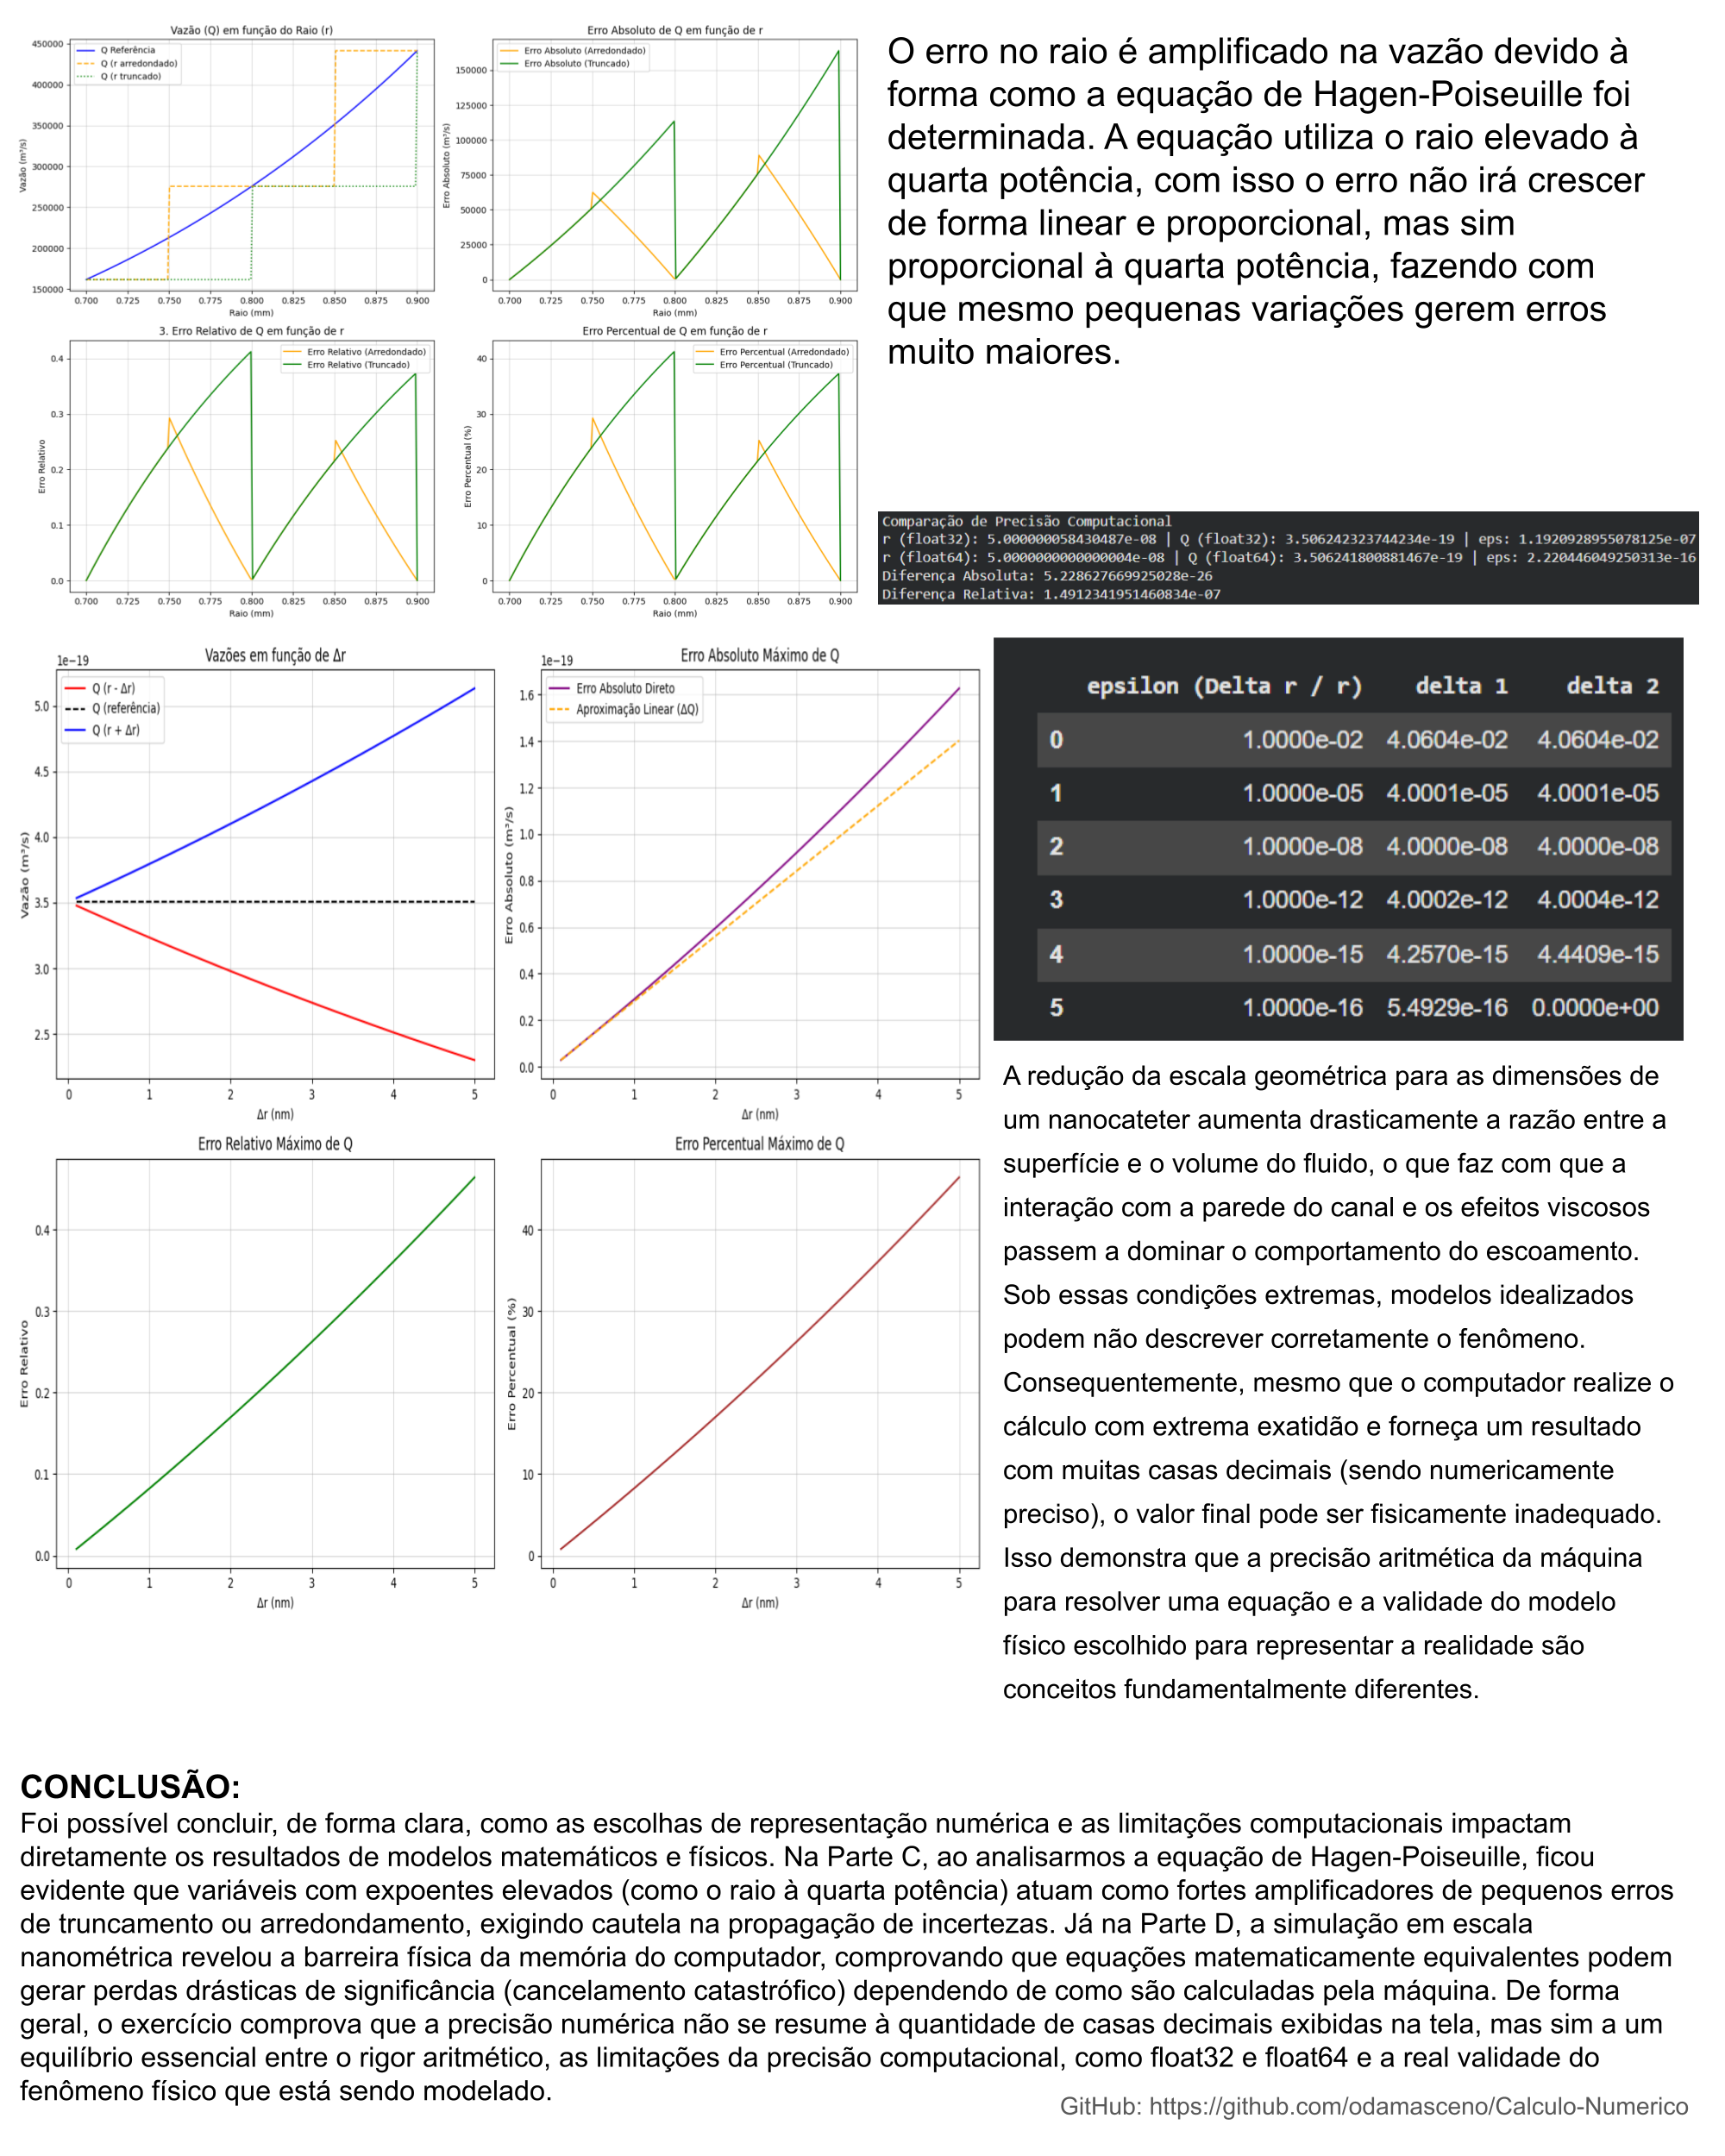

## 8 - GIF Demonstrativo

In [23]:
from matplotlib.animation import FuncAnimation, PillowWriter

#Definindo as Variáveis Iniciais
L_um = 10
u = 3.5 * (10**-3)
dP = 5000
L = L_um * (10**-6)
r_ref_nm = 50
r_ref = r_ref_nm * (10**-9)

Q_ref = HagenPoiseuille(r_ref, dP, u, L)

#Configurando os Quadros do GIF (50 quadros)
num_frames = 50
raios_nm = np.linspace(45, 55, num_frames)
raios_m = raios_nm * (10**-9)
vazoes = HagenPoiseuille(raios_m, dP, u, L)

# Erro percentual em relação a r = 50 nm
erros_perc = 100 * np.abs(vazoes - Q_ref) / np.abs(Q_ref)

#Definições do gif
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Simulação do Nanocateter', fontsize=16, fontweight='bold')


ax1.set_xlim(-60, 60)
ax1.set_ylim(-60, 60)
ax1.set_aspect('equal')
ax1.set_title('Seção Transversal do Canal')
ax1.grid(True, linestyle='--', alpha=0.5)


circulo_ref = plt.Circle((0, 0), 50, color='red', fill=False, linestyle='--', label='Ref (50 nm)')
ax1.add_patch(circulo_ref)

circulo = plt.Circle((0, 0), raios_nm[0], color='blue', alpha=0.5, label='Raio Atual')
ax1.add_patch(circulo)
ax1.legend(loc='upper right')


texto_infos = ax1.text(-55, -55, '', fontsize=10, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))


ax2.set_xlim(44, 56)
ax2.set_ylim(min(vazoes)*0.9, max(vazoes)*1.1)
ax2.set_title('Vazão x Raio')
ax2.set_xlabel('Raio (nm)')
ax2.set_ylabel('Vazão (m³/s)')
ax2.grid(True, linestyle='--', alpha=0.5)

linha, = ax2.plot([], [], 'b-', lw=2)
ponto, = ax2.plot([], [], 'ro')

def update(frame):
    r_atual_nm = raios_nm[frame]
    Q_atual = vazoes[frame]
    erro_atual = erros_perc[frame]

    circulo.set_radius(r_atual_nm)

    texto_infos.set_text(f"Raio Atual: {r_atual_nm:.1f} nm\n"
                         f"Vazão: {Q_atual:.2e} m³/s\n"
                         f"Erro (%): {erro_atual:.2f}%")

    linha.set_data(raios_nm[:frame+1], vazoes[:frame+1])
    ponto.set_data([r_atual_nm], [Q_atual])

    return circulo, texto_infos, linha, ponto

# Gerando a Animação
print("Gerando o GIF")
anim = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)

# 6. Salvando o arquivo
nome_arquivo = 'nanocateter_animacao.gif'
anim.save(nome_arquivo, writer=PillowWriter(fps=10))
plt.close()

print(f"Arquivo '{nome_arquivo}' salvo com sucesso.")

Gerando o GIF
Arquivo 'nanocateter_animacao.gif' salvo com sucesso.


## Conclusão
Foi possível concluir, de forma clara, como as escolhas de representação numérica e as limitações computacionais impactam diretamente os resultados de modelos matemáticos e físicos. Na Parte C, ao analisarmos a equação de Hagen-Poiseuille, ficou evidente que variáveis com expoentes elevados (como o raio à quarta potência) atuam como fortes amplificadores de pequenos erros de truncamento ou arredondamento, exigindo cautela na propagação de incertezas. Já na Parte D, a simulação em escala nanométrica revelou a barreira física da memória do computador, comprovando que equações matematicamente equivalentes podem gerar perdas drásticas de significância (cancelamento catastrófico) dependendo de como são calculadas pela máquina. De forma geral, o exercício comprova que a precisão numérica não se resume à quantidade de casas decimais exibidas na tela, mas sim a um equilíbrio essencial entre o rigor aritmético, as limitações da precisão computacional, como float32 e float64 e a real validade do fenômeno físico que está sendo modelado.


link GitHub: [Rafael Damasceno](https://github.com/odamasceno/Calculo-Numerico)
